# Superstore — Анализ продаж и прибыли
**Датасет:** superstore.csv
**Строк:** 51 290 | **Колонок:** 27 (1 удалена при очистке)
**Стек:** Python · Pandas · Seaborn · Scikit-learn · SciPy

## Часть 1 — Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Загружаем датасет
df = pd.read_csv('superstore.csv')

In [3]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.00,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.00,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.00,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.00,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

In [5]:
# Общая статистика по числовым колонкам
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00
mean,0.14,1.00,28.61,3.48,25645.50,246.50,26.38,2012.78,31.29
std,0.21,0.00,174.34,2.28,14806.29,487.57,57.30,1.10,14.43
min,0.00,1.00,-6599.98,1.00,1.00,0.00,0.00,2011.00,1.00
25%,0.00,1.00,0.00,2.00,12823.25,31.00,2.61,2012.00,20.00
50%,0.00,1.00,9.24,3.00,25645.50,85.00,7.79,2013.00,33.00
75%,0.20,1.00,36.81,5.00,38467.75,251.00,24.45,2014.00,44.00
max,0.85,1.00,8399.98,14.00,51290.00,22638.00,933.57,2014.00,53.00


In [6]:
# Уникальные значения категориальных колонок
print('Сегменты:', df['Segment'].unique())
print('Категории:', df['Category'].unique())
print('Способы доставки:', df['Ship.Mode'].unique())
print('Приоритет заказа:', df['Order.Priority'].unique())
print('Рынки:', df['Market'].unique())

Сегменты: <StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str
Категории: <StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str
Способы доставки: <StringArray>
['Second Class', 'Standard Class', 'Same Day', 'First Class']
Length: 4, dtype: str
Приоритет заказа: <StringArray>
['High', 'Medium', 'Critical', 'Low']
Length: 4, dtype: str
Рынки: <StringArray>
['US', 'EU', 'LATAM', 'Africa', 'APAC', 'EMEA', 'Canada']
Length: 7, dtype: str


## Часть 2 — Очистка данных

In [7]:
# Проверяем пропуски
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [8]:
# Фиксируем размер до очистки
before = len(df)
print(f'Строк до очистки: {before}')

Строк до очистки: 51290


In [9]:
# Удаляем дубликаты
df = df.drop_duplicates()
print(f'Удалено дублей: {before - len(df)}')

Удалено дублей: 0


In [10]:
# Убираем технический мусор:
# - колонка '记录数' (китайское "количество записей") — константа, везде равна 1, смысловой нагрузки не несёт
# - строки с Sales == 0 — на них нельзя посчитать маржу (деление на ноль) и таких строк всего одна
df = df.drop(columns=['记录数'])
df = df[df['Sales'] > 0]
print(f'Строк после удаления мусора: {len(df)}')

Строк после удаления мусора: 51289


In [11]:
# Создаём новые признаки — срок доставки (в днях) и маржа прибыли (Profit / Sales)
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date']  = pd.to_datetime(df['Ship.Date'])

df['delivery_days'] = (df['Ship.Date'] - df['Order.Date']).dt.days
df['profit_margin'] = df['Profit'] / df['Sales']

df[['Order.ID', 'Segment', 'delivery_days', 'profit_margin']].head()

,Order.ID,Segment,delivery_days,profit_margin
0,CA-2011-130813,Consumer,2,0.49
1,CA-2011-148614,Consumer,5,0.49
2,CA-2011-118962,Consumer,4,0.47
3,CA-2011-118962,Consumer,4,0.48
4,CA-2011-146969,Consumer,4,0.52


In [12]:
print(f'Строк после очистки: {len(df)}')
print(f'Удалено всего: {before - len(df)}')

Строк после очистки: 51289
Удалено всего: 1


## Часть 3 — Разведочный анализ (EDA)

/tmp/ipykernel_638/249155905.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')


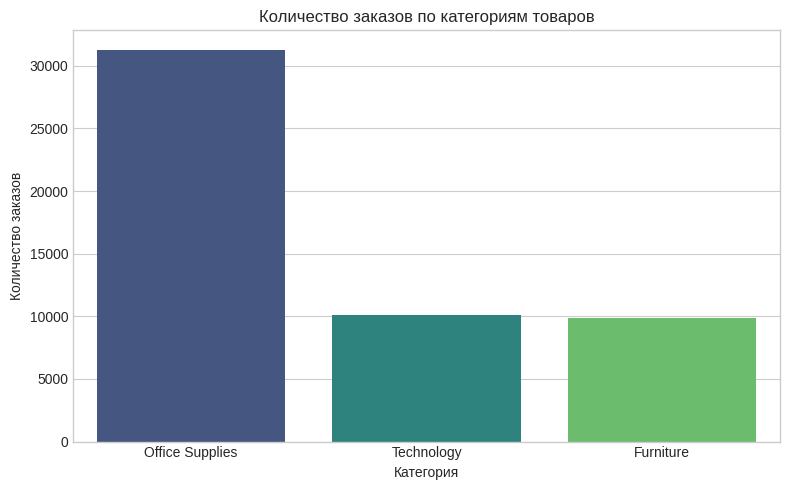

Category
Office Supplies    31272
Technology         10141
Furniture           9876
Name: count, dtype: int64


In [13]:
# Распределение заказов по категориям товаров
cat_counts = df['Category'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
plt.title('Количество заказов по категориям товаров')
plt.xlabel('Категория')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

print(cat_counts)
# Вывод: Office Supplies — самая крупная категория (61% заказов),
# Furniture и Technology делят оставшуюся часть примерно пополам

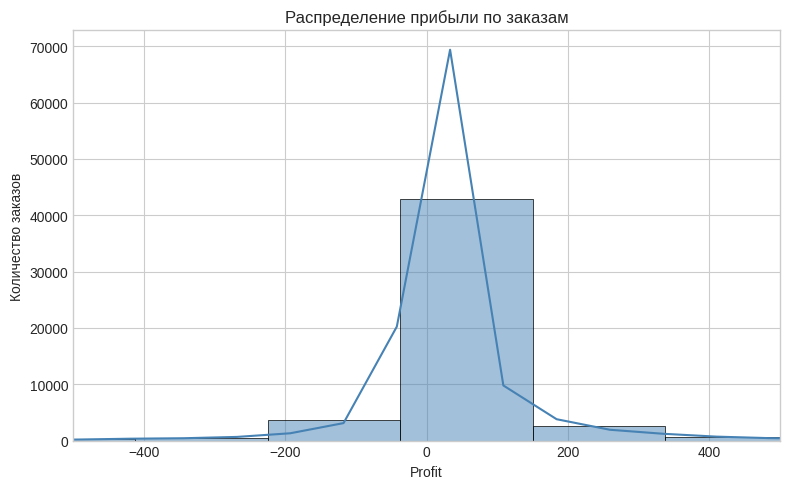

In [14]:
# Распределение прибыли по заказам
plt.figure(figsize=(8, 5))
sns.histplot(df['Profit'], bins=80, kde=True, color='steelblue')
plt.xlim(-500, 500)
plt.title('Распределение прибыли по заказам')
plt.xlabel('Profit')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

# Вывод: большинство заказов приносят прибыль от 0 до 100,
# но заметная доля заказов уходит в минус (убыточные продажи со скидкой)

/tmp/ipykernel_638/996515121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Profit',


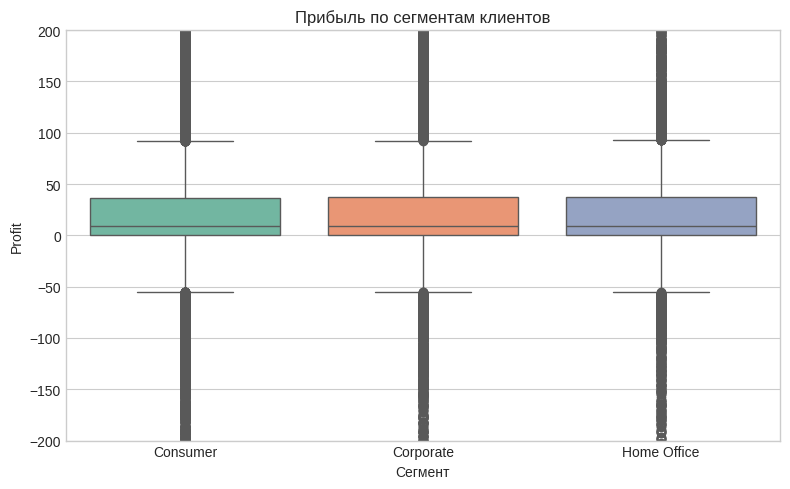

In [15]:
# Прибыль по сегментам клиентов
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Segment', y='Profit',
            order=['Consumer', 'Corporate', 'Home Office'], palette='Set2')
plt.ylim(-200, 200)
plt.title('Прибыль по сегментам клиентов')
plt.xlabel('Сегмент')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

# Вывод: медианы и разброс прибыли у Consumer, Corporate и Home Office визуально очень похожи

/tmp/ipykernel_638/1253098814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Market', y='Profit', order=market_order, palette='Blues_d')


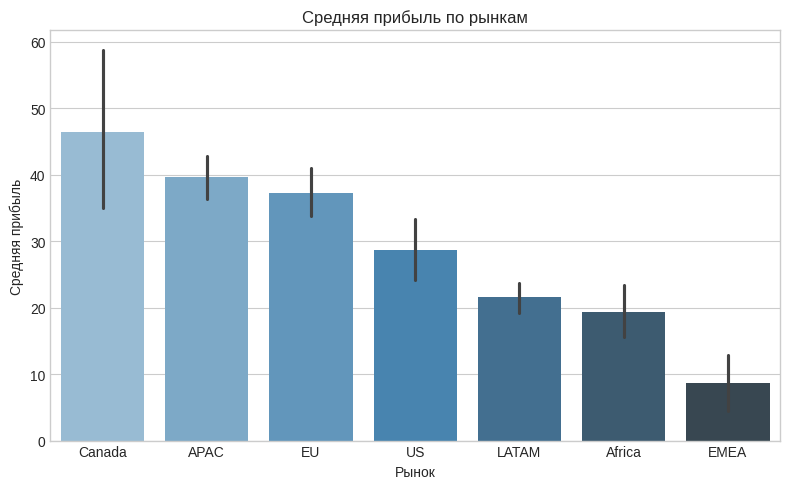

In [16]:
# Средняя прибыль по рынкам (Market)
market_order = df.groupby('Market')['Profit'].mean().sort_values(ascending=False).index

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Market', y='Profit', order=market_order, palette='Blues_d')
plt.title('Средняя прибыль по рынкам')
plt.xlabel('Рынок')
plt.ylabel('Средняя прибыль')
plt.tight_layout()
plt.show()

# Вывод: Canada и APAC приносят наибольшую среднюю прибыль с заказа, EMEA — наименьшую

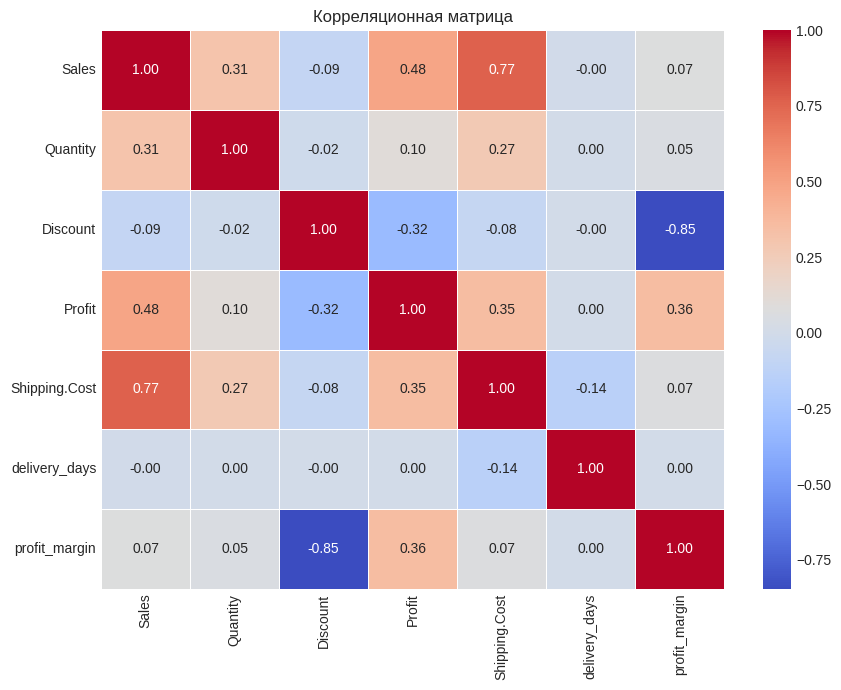

In [17]:
# Корреляционная матрица числовых признаков
num_df = df[['Sales', 'Quantity', 'Discount', 'Profit',
             'Shipping.Cost', 'delivery_days', 'profit_margin']]

plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

# Вывод: Discount сильно отрицательно коррелирует с profit_margin (~-0.85) —
# скидка является главным фактором, разрушающим маржинальность заказа

## Часть 4 — Ключевые метрики

In [18]:
# Средняя маржа прибыли по категориям товаров
margin_by_cat = df.groupby('Category')['profit_margin'].mean().sort_values(ascending=False).reset_index()
margin_by_cat.columns = ['Категория', 'Средняя маржа']

print(margin_by_cat)
# Вывод: Office Supplies даёт самую высокую маржу (~6%), Furniture — самую низкую (~1%)

         Категория  Средняя маржа
0  Office Supplies           0.06
1       Technology           0.05
2        Furniture           0.01


In [19]:
# Доля прибыльных заказов — аналог "Retention Rate" для розницы:
# какая часть заказов вообще выходит в плюс по прибыли
profitable_share = (df['Profit'] > 0).mean()

print(f'Доля прибыльных заказов: {profitable_share:.1%}')
# Вывод: почти три четверти заказов прибыльны, остальные — убыточны

Доля прибыльных заказов: 74.2%


In [20]:
# Сводная таблица метрик по сегментам клиентов
summary = df.groupby('Segment').agg(
    orders=('Order.ID', 'count'),
    avg_sales=('Sales', 'mean'),
    avg_profit=('Profit', 'mean'),
    avg_discount=('Discount', 'mean'),
    avg_shipping_cost=('Shipping.Cost', 'mean'),
    avg_margin=('profit_margin', 'mean')
).round(2)

summary

,orders,avg_sales,avg_profit,avg_discount,avg_shipping_cost,avg_margin
Segment,,,,,,
Consumer,26517,245.43,28.26,0.14,26.30,0.05
Corporate,15429,247.90,28.60,0.14,26.60,0.05
Home Office,9343,247.24,29.65,0.14,26.23,0.05


## Часть 5 — Линейная регрессия

In [21]:
# Цель: предсказать прибыль заказа (Profit) по его характеристикам
features = ['Sales', 'Quantity', 'Discount', 'Shipping.Cost', 'delivery_days']
target = 'Profit'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R²  = {r2:.3f}   — модель объясняет {r2*100:.1f}% вариации прибыли')
print(f'MAE = {mae:.2f}  — средняя ошибка предсказания')

R²  = 0.162   — модель объясняет 16.2% вариации прибыли
MAE = 59.27  — средняя ошибка предсказания


/tmp/ipykernel_638/1611774134.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette='RdBu')


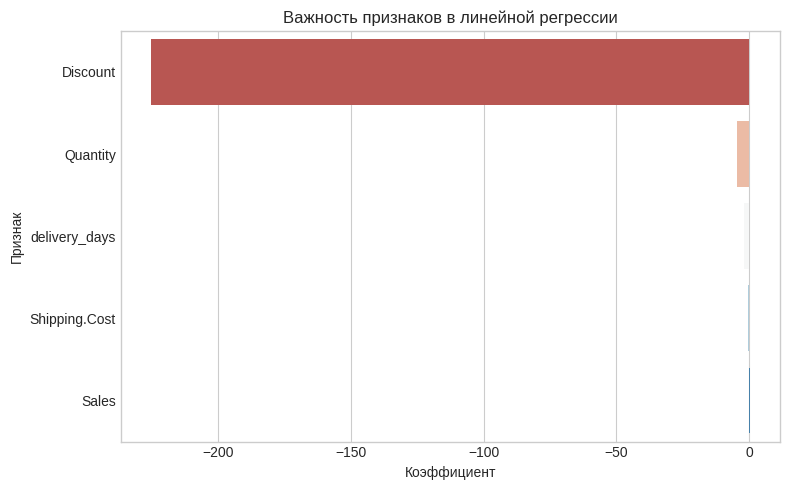

In [24]:
# Важность признаков
coef_df = pd.DataFrame({'Признак': features, 'Коэффициент': model.coef_})
coef_df = coef_df.reindex(coef_df['Коэффициент'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette='RdBu')
plt.title('Важность признаков в линейной регрессии')
plt.tight_layout()
plt.show()

# Вывод: Discount — главный предиктор прибыли с большим отрицательным коэффициентом,
# Sales положительно влияет на прибыль, остальные признаки значительно слабее

## Часть 6 — Проверка гипотез

In [25]:
# Гипотеза 1: Скидка более 20% снижает прибыль
high_disc = df[df['Discount'] > 0.2]['Profit']
low_disc  = df[df['Discount'] <= 0.2]['Profit']

t_stat, p_value = stats.ttest_ind(high_disc, low_disc, equal_var=False)

print(f'Средняя прибыль (скидка > 20%):  {high_disc.mean():.2f}')
print(f'Средняя прибыль (скидка <= 20%): {low_disc.mean():.2f}')
print('p-value =', f'{p_value:.4f}' if p_value >= 0.0001 else '< 0.0001')

if p_value < 0.05 and high_disc.mean() < low_disc.mean():
    print('✅ Гипотеза подтверждена — скидка более 20% статистически значимо снижает прибыль')
else:
    print('❌ Гипотеза не подтверждена')

Средняя прибыль (скидка > 20%):  -71.92
Средняя прибыль (скидка <= 20%): 57.11
p-value = < 0.0001
✅ Гипотеза подтверждена — скидка более 20% статистически значимо снижает прибыль


In [26]:
# Гипотеза 2: Быстрая доставка повышает прибыль
# "Быстрая доставка" — срок доставки не выше медианного (<= 3 дней), остальное — медленная
median_days = df['delivery_days'].median()
fast = df[df['delivery_days'] <= median_days]['Profit']
slow = df[df['delivery_days'] >  median_days]['Profit']

t_stat, p_value = stats.ttest_ind(fast, slow, equal_var=False)

print(f'Медианный срок доставки: {median_days:.0f} дней')
print(f'Средняя прибыль (быстрая доставка): {fast.mean():.2f}')
print(f'Средняя прибыль (медленная доставка): {slow.mean():.2f}')
print(f'p-value = {p_value:.4f}')

if p_value < 0.05 and fast.mean() > slow.mean():
    print('✅ Гипотеза подтверждена — быстрая доставка статистически значимо повышает прибыль')
else:
    print('❌ Гипотеза не подтверждена — статистически значимой разницы не обнаружено')

Медианный срок доставки: 4 дней


Средняя прибыль (быстрая доставка): 28.53
Средняя прибыль (медленная доставка): 28.73
p-value = 0.8992
❌ Гипотеза не подтверждена — статистически значимой разницы не обнаружено


In [27]:
# Гипотеза 3: Корпоративные клиенты (Corporate) делают более прибыльные заказы, чем обычные (Consumer)
corporate = df[df['Segment'] == 'Corporate']['Profit']
consumer  = df[df['Segment'] == 'Consumer']['Profit']

t_stat, p_value = stats.ttest_ind(corporate, consumer, equal_var=False)

print(f'Средняя прибыль (Corporate): {corporate.mean():.2f}')
print(f'Средняя прибыль (Consumer):  {consumer.mean():.2f}')
print(f'p-value = {p_value:.4f}')

if p_value < 0.05 and corporate.mean() > consumer.mean():
    print('✅ Гипотеза подтверждена — заказы Corporate статистически значимо прибыльнее')
else:
    print('❌ Гипотеза не подтверждена — статистически значимой разницы не обнаружено')

Средняя прибыль (Corporate): 28.60
Средняя прибыль (Consumer):  28.26
p-value = 0.8483
❌ Гипотеза не подтверждена — статистически значимой разницы не обнаружено


## Часть 7 — Выводы и рекомендации

In [28]:
print("""
КЛЮЧЕВЫЕ ВЫВОДЫ
===============
1. Скидка — главный враг прибыли: корреляция Discount с маржой ≈ -0.85,
   при скидке выше 20% заказы в среднем становятся убыточными
   (доля прибыльных заказов падает с ~92% до ~10%).
2. Срок доставки практически не влияет на прибыль заказа — статистически
   значимой разницы между "быстрыми" и "медленными" заказами не обнаружено.
3. Сегмент клиента (Corporate / Consumer / Home Office) почти не влияет
   на прибыльность заказа — средняя прибыль и маржа у всех сегментов близки.
4. Office Supplies — самая массовая и при этом самая маржинальная категория,
   Furniture — самая низкомаржинальная.
5. Линейная регрессия объясняет лишь часть вариации прибыли (низкий R²) —
   на прибыль заказа влияют и другие факторы (категория товара, регион и т.д.),
   не входящие в простую линейную модель.

РЕКОМЕНДАЦИИ БИЗНЕСУ
====================
1. Ограничить или пересмотреть политику скидок выше 20% — именно они
   систематически приводят заказы в минус.
2. Не использовать ускоренную доставку как способ повышения прибыли —
   она не даёт измеримого финансового эффекта, решение о её использовании
   стоит принимать исходя из качества сервиса, а не из ожидаемой прибыли.
3. Сосредоточить усилия по допродажам на категории Office Supplies
   и анализировать причины низкой маржинальности Furniture.
""")


КЛЮЧЕВЫЕ ВЫВОДЫ
1. Скидка — главный враг прибыли: корреляция Discount с маржой ≈ -0.85,
   при скидке выше 20% заказы в среднем становятся убыточными
   (доля прибыльных заказов падает с ~92% до ~10%).
2. Срок доставки практически не влияет на прибыль заказа — статистически
   значимой разницы между "быстрыми" и "медленными" заказами не обнаружено.
3. Сегмент клиента (Corporate / Consumer / Home Office) почти не влияет
   на прибыльность заказа — средняя прибыль и маржа у всех сегментов близки.
4. Office Supplies — самая массовая и при этом самая маржинальная категория,
   Furniture — самая низкомаржинальная.
5. Линейная регрессия объясняет лишь часть вариации прибыли (низкий R²) —
   на прибыль заказа влияют и другие факторы (категория товара, регион и т.д.),
   не входящие в простую линейную модель.

РЕКОМЕНДАЦИИ БИЗНЕСУ
1. Ограничить или пересмотреть политику скидок выше 20% — именно они
   систематически приводят заказы в минус.
2. Не использовать ускоренную доставку как способ по